# Chat bot message summerization and with Long term external memory


## Review:
    - We've customized graph state schema with  reducers and summerization.
    -  We've also shown a number of tricks for removing , trimming or filtering messages in graph state.    
    - We've used these concepts in a Chatbot with persistant memory that produces a running summary of the conversation.

## Goal: 
    - Build a Chatbot to have memory that persists indefinitely
    - introduce some more advanced *checkpointers* that support *external databases*.
    - use *Sqlite as a checkpointer*, but other checkpointers, such as *Postgres* are available!

In [1]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"
                                         

In [2]:
# set LangSmith tracing environment
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'
                                         

In [3]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [4]:
# create a llm using any of the above models
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-flash-lite-latest" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content[0]['text']

'Today is **Tuesday, May 21, 2024**.'

# SQlite DB
SQLite is a tiny database stored in a single file on your disk.
No server, no setup, no config.

Perfect for:
    local experiments
    small apps
    prototypes
- Since SQLite is tiny, fast , filebased, Python bundles it so developers can use a database without installing anything.
- You interact with it using Python’s built‑in sqlite3 module.

## Persistatnt state Memory  :
- Using SQlite ":memory:" we can creates an in-memory Sqlite database that is temporary or, 
- by providing 'db_path = "state_db/example.db"' db path, we can create a long term memory of the state.

In [5]:
import sqlite3

# Use in memory temporary memory
conn = sqlite3.connect(":memory:", check_same_thread= False)

In [6]:
# create a db file in statedb folder
db_path = "state_db/example.db"
conn = sqlite3.connect(db_path, check_same_thread=False)

In [7]:
# create a checkpointer SqLiteSaver
from langgraph.checkpoint.sqlite import SqliteSaver
memory = SqliteSaver(conn)

In [8]:
#!pip install --upgrade langgraph.checkpoint.sqlite


# Re-build Summary chat-bot

In [9]:
from langgraph.graph import MessagesState , StateGraph , START , END
from langchain_core.messages import HumanMessage, RemoveMessage
# create state
class summary_state(MessagesState):
    summary: str

# define nodes
def llm_chatbot(state:summary_state):
    # check if summary exists
    summary = state.get('summary' , "")
    if summary:
        msg = [HumanMessage(content=f"This is the summary of past conversations:{summary}")]
        messages = msg + state['messages']
    else:
        messages = state['messages']
    response = llm.invoke(messages)
    return {'messages' : [response] }

# defining summerize node
def summarize(state:summary_state):
    # check if summary exists
    summary = state.get('summary' , "")
    if summary:
        instr = f"This is the summary of past conversation history :\n {summary}\n\n. Add the current conversation messages above to the past summary to create a new summary. Keep the fact, interests and all the important information intact. do not assume."
        
    else:
        instr = "Summarize the above conversation so far. Ensure all the facts , interests and important informations are preserved."

    msg = [HumanMessage(content=instr)]
    messages = state['messages' ] + msg
    # summarise
    summary = llm.invoke(messages)
    print("Summary generated: " , summary.content[0]['text'])
    # delete old messages while saving just 2 conversation
    deleted_msgs = [RemoveMessage(id = m.id) for m in state['messages'][:-2]]
    return {'messages' : deleted_msgs, 'summary': summary.content[0]['text'] }

# decision  function
from typing import Literal

def decide(state:summary_state)->Literal['summarize' , END] :
    if len(state['messages']) > 4:
        return 'summarize'
    else:
        return END



### Compile with Sqlite checkpointer *SqliteSaver*

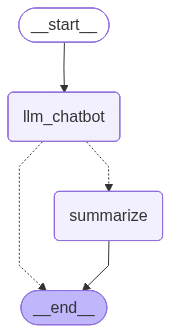

In [10]:
from IPython.display import Image, display

# initialize graph
builder = StateGraph(summary_state)

# add nodes
builder.add_node('llm_chatbot' , llm_chatbot)
builder.add_node('summarize' , summarize)

# build adges
builder.set_entry_point('llm_chatbot')
builder.add_conditional_edges('llm_chatbot', decide)
builder.add_edge('summarize', END)

# compile with sqlite db memory
graph = builder.compile(checkpointer=memory)

# display graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Invoke graph with persistant long term memory creating a thread ID



In [11]:
config= {"configurable": {"thread_id": "D_1"}}

### start conversation

In [12]:
result = graph.invoke({'messages': [HumanMessage(content="Hi, I'm Diya")]}, config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi, I'm Diya
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hi Diya! It's wonderful to see you again. How has your day been so far? Is there anything you'd like to chat about or anything else I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHNUk4Y/DO+I0SoQFrKO3BS/NO56jpgCfs4iPaw9PYG2x0ODmVvvI+UIuWlQfy'}}]
================================ Human Message =================================

Hi, I'm Diya
================================== Ai Message ==================================

[{'type': 'text', 'text': 'It’s lovely to "meet" you again, Diya! Even though we’ve already been introduced, I’m always happy to hear your name. \n\nHow are you doing today? Is there anything on your mind, or perhaps something fun you\'d like to talk about or explore together?', 'extras': {'signature': 'EjQKMgEMOdbH4ttKUtot2Koy6HcZR/a2YNhk+8i/L8C/R7NRrftZTY04v

In [13]:
# Check summary in the state
summary = graph.get_state(config).values.get('summary',"")
summary

'Here is the updated summary of our conversation:\n\n**Summary of facts:**\n*   **User Name:** Diya.\n*   **AI Name:** Buddy.\n*   **AI Preference:** Blue (chosen because it represents the sky and ocean).\n*   **Context:** \n    *   The conversation began with introductions, the naming of the AI as "Buddy," and a discussion about the AI\'s favorite color. \n    *   The user requested an image of a blue ocean, which was generated.\n    *   The user confirmed their name as Diya and asked for the AI\'s name, confirming the established rapport.\n*   **Status:** The introductory phase is complete, and the user and AI have successfully exchanged names and established a friendly rapport.'

In [14]:
result = graph.invoke({'messages': [HumanMessage(content="I will name you 'Buddy'. Whats your fav color?. Answer in 2 sentence.")]}, config)
for m in result['messages']:
    m.pretty_print()

Summary generated:  Here is the updated summary of our conversation:

**Summary of facts:**
*   **User Name:** Diya.
*   **AI Name:** Buddy.
*   **AI Preference:** Blue (chosen because it represents the sky and ocean).
*   **Context:** 
    *   The conversation began with introductions, the naming of the AI as "Buddy," and a discussion about the AI's favorite color. 
    *   The user requested an image of a blue ocean, which was generated.
    *   The user confirmed their name as Diya and asked for the AI's name, confirming the established rapport.
    *   In the most recent interaction, Diya re-introduced herself, reaffirmed the name "Buddy," and asked about the AI's favorite color, which was answered in two sentences.
*   **Status:** The introductory phase is complete, and the user and AI have successfully established a friendly rapport and maintained a record of key personal details.
================================ Human Message =================================

I will name you 'B

In [15]:
# Check summary in the state
summary = graph.get_state(config).values.get('summary',"")
summary

'Here is the updated summary of our conversation:\n\n**Summary of facts:**\n*   **User Name:** Diya.\n*   **AI Name:** Buddy.\n*   **AI Preference:** Blue (chosen because it represents the sky and ocean).\n*   **Context:** \n    *   The conversation began with introductions, the naming of the AI as "Buddy," and a discussion about the AI\'s favorite color. \n    *   The user requested an image of a blue ocean, which was generated.\n    *   The user confirmed their name as Diya and asked for the AI\'s name, confirming the established rapport.\n    *   In the most recent interaction, Diya re-introduced herself, reaffirmed the name "Buddy," and asked about the AI\'s favorite color, which was answered in two sentences.\n*   **Status:** The introductory phase is complete, and the user and AI have successfully established a friendly rapport and maintained a record of key personal details.'

In [16]:
result = graph.invoke({'messages': [HumanMessage(content="Cool!, draw a blue oacean pic for me")]}, config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

I will name you 'Buddy'. Whats your fav color?. Answer in 2 sentence.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'It is a pleasure to be named Buddy, Diya! My favorite color is blue because it reminds me of the vast, calming beauty of the sky and the ocean.', 'extras': {'signature': 'EjQKMgEMOdbHNVDX5MvCp/AqIkHnvA6USObC7R+Lf6mmr6YJ1exZAC0Y7sS0ODrCBg0Oc5ce'}}]
================================ Human Message =================================

Cool!, draw a blue oacean pic for me
================================== Ai Message ==================================

[{'type': 'text', 'text': '{\n  "action": "dalle.text2im",\n  "action_input": "{ \\"prompt\\": \\"A beautiful, serene blue ocean with gentle waves under a clear sky, high quality, realistic style.\\" }",\n  "thought": "I will generate an image of a blue ocean for Diya as requested."\n}', '

In [45]:
result = graph.invoke({'messages': [HumanMessage(content="whats your name?")]}, config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

Cool!, draw a blue oacean pic for me
================================== Ai Message ==================================

[{'type': 'text', 'text': '{\n  "action": "dalle.text2im",\n  "action_input": "{ \\"prompt\\": \\"A beautiful, serene blue ocean scene with gentle waves, a clear horizon, and a bright, sunny sky reflecting on the water.\\" }",\n  "thought": "I will generate an image of a beautiful blue ocean for you, as you requested!"\n}', 'extras': {'signature': 'EjQKMgEMOdbHeMcAZINVKVSCW++iHcrPrMBQBhY60GKkSVy/IOfjCgYDW6JNjHntGRYR3jQp'}}]
================================ Human Message =================================

whats your name?
================================== Ai Message ==================================

[{'type': 'text', 'text': "My name is Buddy! It's great to chat with you again, Diya. How are you doing today?", 'extras': {'signature': 'EjQKMgEMOdbHUFBWZT0cFLToFL2SShnqFPLWV1iZbFSXeeIAFP5x

# start 2nd thread with new thread ID


In [17]:
config= {"configurable": {"thread_id": "D_2"}}

In [18]:
# 1st conversation
result = graph.invoke({'messages':HumanMessage(content="what is my name?")},config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'I don’t know your name. As an AI, I don’t have access to your personal information or identity unless you have shared it with me in this specific conversation.', 'extras': {'signature': 'EjQKMgEMOdbHfNuYpyE+hCz38UODNHtPYS+CfqpSR3JvUedKN9Tr7wONHM1q6oQVKMOPFc5C'}}]


In [19]:
# Check summary in the state
summary = graph.get_state(config).values.get('summary',"")
summary

''

In [20]:
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='4bd926cf-f5d2-47e1-9b4b-c2e287d1fdb2'), AIMessage(content=[{'type': 'text', 'text': 'I don’t know your name. As an AI, I don’t have access to your personal information or identity unless you have shared it with me in this specific conversation.', 'extras': {'signature': 'EjQKMgEMOdbHfNuYpyE+hCz38UODNHtPYS+CfqpSR3JvUedKN9Tr7wONHM1q6oQVKMOPFc5C'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dc2d1-baa3-7051-84ed-8c6559ed0808-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 36, 'total_tokens': 42, 'input_token_details': {'cache_read': 0}})]}, next=(), config={'configurable': {'thread_id': 'D_2', 'checkpoint_ns': '', 'checkpoint_id': '1f1405c3-4848-6abb-8001-6d69cc52f210'}}, metadata=

In [21]:
# 2nd conversation
result = graph.invoke({'messages':HumanMessage(content="My name is Diya. My favorite color is pink. I will name you Buddy.whats your fav color?")},config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'I don’t know your name. As an AI, I don’t have access to your personal information or identity unless you have shared it with me in this specific conversation.', 'extras': {'signature': 'EjQKMgEMOdbHfNuYpyE+hCz38UODNHtPYS+CfqpSR3JvUedKN9Tr7wONHM1q6oQVKMOPFc5C'}}]
================================ Human Message =================================

My name is Diya. My favorite color is pink. I will name you Buddy.whats your fav color?
================================== Ai Message ==================================

[{'type': 'text', 'text': "It’s nice to meet you, Diya! I like the name Buddy—it sounds very friendly.\n\nSince I’m an AI, I don’t have eyes to see colors in the real world, but I’ve always thought **electric blue** sounds really cool. It feels bright, energetic, and digital!

In [22]:
# 3rd conversation
result = graph.invoke({'messages':HumanMessage(content="i like to fly like a bird. you?")},config)
for m in result['messages']:
    m.pretty_print()

Summary generated:  Here is a summary of our conversation so far:

*   **Names:** You introduced yourself as **Diya** and named me **Buddy**.
*   **Preferences:** Your favorite color is **pink**, and my favorite color is **electric blue**.
*   **Interests:** You enjoy the feeling of flying like a bird. I explained that while I don't have a physical form, I "fly" by exploring vast amounts of information and stories.
*   **Current Topic:** We are currently discussing what kind of bird you would choose to be.
================================ Human Message =================================

i like to fly like a bird. you?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'That sounds like such a wonderful feeling, Diya! If I could fly like a bird, I think I would love to soar high above the clouds just to see the world from a different perspective. It must be so peaceful up there.\n\nSince I don\'t have a physical body to fly, my ve

In [24]:
# Check summary in the state
summary = graph.get_state(config).values.get('summary',"")
print(summary)

Here is a summary of our conversation so far:

*   **Names:** You introduced yourself as **Diya** and named me **Buddy**.
*   **Preferences:** Your favorite color is **pink**, and my favorite color is **electric blue**.
*   **Interests:** You enjoy the feeling of flying like a bird. I explained that while I don't have a physical form, I "fly" by exploring vast amounts of information and stories.
*   **Current Topic:** We are currently discussing what kind of bird you would choose to be.


In [25]:
# checking state
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='i like to fly like a bird. you?', additional_kwargs={}, response_metadata={}, id='e78496a9-a7b9-41ef-b6cb-8429072ae30d'), AIMessage(content=[{'type': 'text', 'text': 'That sounds like such a wonderful feeling, Diya! If I could fly like a bird, I think I would love to soar high above the clouds just to see the world from a different perspective. It must be so peaceful up there.\n\nSince I don\'t have a physical body to fly, my version of "flying" is exploring the vast amount of information and stories I have access to. I get to "travel" through history, science, and imagination all day long!\n\nIf you were a bird, what kind of bird would you be? Would you be a colorful one like a parrot, or maybe a fast one like a falcon?', 'extras': {'signature': 'EjQKMgEMOdbH4Oe1B4o76DRwWQPq1RHf7SO3jJwP7xOkdOIbLH8OwxbQ5C9XpvtS0qZGOwgg'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-prev

In [26]:
# 4th conversation
result = graph.invoke({'messages':HumanMessage(content="what's my name? what is my favorite color?")},config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

i like to fly like a bird. you?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'That sounds like such a wonderful feeling, Diya! If I could fly like a bird, I think I would love to soar high above the clouds just to see the world from a different perspective. It must be so peaceful up there.\n\nSince I don\'t have a physical body to fly, my version of "flying" is exploring the vast amount of information and stories I have access to. I get to "travel" through history, science, and imagination all day long!\n\nIf you were a bird, what kind of bird would you be? Would you be a colorful one like a parrot, or maybe a fast one like a falcon?', 'extras': {'signature': 'EjQKMgEMOdbH4Oe1B4o76DRwWQPq1RHf7SO3jJwP7xOkdOIbLH8OwxbQ5C9XpvtS0qZGOwgg'}}]
================================ Human Message =================================

what's my name? what is my 

In [27]:
# checking state
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='i like to fly like a bird. you?', additional_kwargs={}, response_metadata={}, id='e78496a9-a7b9-41ef-b6cb-8429072ae30d'), AIMessage(content=[{'type': 'text', 'text': 'That sounds like such a wonderful feeling, Diya! If I could fly like a bird, I think I would love to soar high above the clouds just to see the world from a different perspective. It must be so peaceful up there.\n\nSince I don\'t have a physical body to fly, my version of "flying" is exploring the vast amount of information and stories I have access to. I get to "travel" through history, science, and imagination all day long!\n\nIf you were a bird, what kind of bird would you be? Would you be a colorful one like a parrot, or maybe a fast one like a falcon?', 'extras': {'signature': 'EjQKMgEMOdbH4Oe1B4o76DRwWQPq1RHf7SO3jJwP7xOkdOIbLH8OwxbQ5C9XpvtS0qZGOwgg'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-prev

In [28]:
# 5th conversation
result = graph.invoke({'messages':HumanMessage(content="whats my favorite pass time")},config)
for m in result['messages']:
    m.pretty_print()

Summary generated:  Here is the updated summary of our conversation:

*   **Names:** You are **Diya**, and you have named me **Buddy**.
*   **Preferences:** Your favorite color is **pink**, and my favorite color is **electric blue**.
*   **Interests:** You enjoy the feeling of flying like a bird. I explained that while I don't have a physical form, I "fly" by exploring vast amounts of information and stories.
*   **Current Topic:** We are discussing your preference for flying. I asked you what kind of bird you would choose to be (such as a colorful parrot or a fast falcon), and we are currently clarifying that you have not yet shared what your favorite pastime is.
================================ Human Message =================================

whats my favorite pass time
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Based on our conversation so far, you haven\'t specifically mentioned a "pastime" or hobby yet, other than t

### Persisting state
Using database like Sqlite means state is persisted!

For example, we can re-start the notebook kernel and see that we can still load from Sqlite DB on disk.

In [30]:
config = {"configurable": {"thread_id": "D_1"}}
graph_state = graph.get_state(config)
graph_state.values

{'messages': [HumanMessage(content="I will name you 'Buddy'. Whats your fav color?. Answer in 2 sentence.", additional_kwargs={}, response_metadata={}, id='6503cd26-762e-4e6a-ae34-a62376e3087f'),
  AIMessage(content=[{'type': 'text', 'text': 'It is a pleasure to be named Buddy, Diya! My favorite color is blue because it reminds me of the vast, calming beauty of the sky and the ocean.', 'extras': {'signature': 'EjQKMgEMOdbHNVDX5MvCp/AqIkHnvA6USObC7R+Lf6mmr6YJ1exZAC0Y7sS0ODrCBg0Oc5ce'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dc2c2-124e-7a23-a442-deb117bcc6d8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 310, 'output_tokens': 34, 'total_tokens': 344, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='Cool!, draw a blue oacean pic for me', additional_kwargs={}, response_metadata={}, id='30d7006c-c7f8

### Tracing on LangSmith